# QM640 Capstone — 03_Modeling.ipynb
## Final Modeling: RQ1–RQ4

This notebook completes the core statistical and machine-learning modeling for the capstone and explicitly addresses the interim-evaluation feedback.

### Critical corrections incorporated
1. **Target definition:** the final confirmatory outcome is `financial_severity_log = log(1 + total_observed_loss_usd)`, where total observed loss combines NOAA-reported property damage and NFIP flood payouts at the **county-year** level. It is therefore interpreted as an **integrated county-year financial-severity proxy**, not as event-level multi-peril insurance claim severity.
2. **NFIP coverage limitation:** NFIP is flood insurance only. The NOAA hazard variables cover multiple hazard types. County-year matching therefore supports ecological association, not event-level causal attribution of NFIP payments to non-flood hazards.
3. **Target leakage control:** the interim `severity_metric` was constructed partly from hazard and loss variables. For RQ3, this notebook creates a **loss-only classification target** and excludes every loss/target-derived field from the predictor set.
4. **Minimum sample size:** explicit calculations are provided for RQ1–RQ4 rather than adequacy statements alone.

In [1]:
from pathlib import Path
import warnings, json, math, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, f, ncf, theilslopes

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay, mean_absolute_error,
                             mean_squared_error)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import joblib

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
DATA_PATH = ROOT / 'data' / 'processed' / 'catastrophe_dataset.csv'
FIG_DIR = ROOT / 'figures' / 'modeling'
TABLE_DIR = ROOT / 'report_ready_tables' / 'modeling'
DOC_DIR = ROOT / 'documentation'
MODEL_DIR = ROOT / 'models'
for d in [FIG_DIR, TABLE_DIR, DOC_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT.resolve())
print('XGBoost available:', XGBOOST_AVAILABLE)

Project root: /mnt/data/QM640_Final_Modeling_Package
XGBoost available: True


In [2]:
df = pd.read_csv(DATA_PATH, dtype={'county_fips': str})
df['county_fips'] = df['county_fips'].str.zfill(5)
assert len(df) == 903
assert df.duplicated(['year','county_fips']).sum() == 0

# Final confirmatory financial-severity target.
df['financial_severity_log'] = np.log1p(df['total_observed_loss_usd'])
financial_threshold = df['financial_severity_log'].quantile(0.80)
df['high_financial_severity_flag'] = (df['financial_severity_log'] >= financial_threshold).astype(int)

# Flood-claim-specific sensitivity outcome (interpret only as NFIP claim severity).
df['avg_nfip_payout_per_claim_usd'] = np.where(
    df['nfip_claim_count'] > 0,
    df['total_nfip_payout_usd'] / df['nfip_claim_count'],
    np.nan
)
df['log_avg_nfip_payout_per_claim'] = np.log1p(df['avg_nfip_payout_per_claim_usd'])

summary = pd.DataFrame({
    'Metric':['Rows','Columns','Years','Counties','Financial severity 80th percentile','High financial severity observations','NFIP matched county-years'],
    'Value':[len(df),df.shape[1],f"{df.year.min()}–{df.year.max()}",df.county_fips.nunique(),financial_threshold,int(df.high_financial_severity_flag.sum()),int(df.nfip_record_available.sum())]
})
summary.to_csv(TABLE_DIR/'01_modeling_dataset_summary.csv',index=False)
summary

,Metric,Value
0,Rows,903
1,Columns,44
2,Years,2000–2023
3,Counties,50
4,Financial severity 80th percentile,15.388792
5,High financial severity observations,181
6,NFIP matched county-years,902


## Target definition and leakage-control matrix
The interim composite severity index remains available for continuity with the interim report, but it is **not** used as the final RQ3 classification target because its construction includes hazard and loss components. The final RQ3 target is the top 20% of the loss-only `financial_severity_log` outcome. All direct or transformed loss fields are excluded from RQ3 predictors.

In [3]:
leakage_rows = [
    ['severity_metric','Interim target','Constructed from wind, hail, flood, duration, NOAA damage, NFIP payout','Do not use as final RQ3 target'],
    ['high_severity_flag','Interim classification target','Derived from severity_metric','Do not use as final RQ3 target'],
    ['property_damage_usd','Loss component','Direct component of final financial target','Excluded from RQ3 predictors'],
    ['total_nfip_payout_usd','Loss component','Direct component of final financial target','Excluded from RQ3 predictors'],
    ['total_observed_loss_usd','Final target precursor','Direct precursor of financial_severity_log','Excluded from RQ3 predictors'],
    ['log_property_damage','Transformed loss','Derived from target component','Excluded from RQ3 predictors'],
    ['log_total_nfip_payout','Transformed loss','Derived from target component','Excluded from RQ3 predictors'],
    ['log_total_observed_loss','Equivalent target transform','Equivalent to financial_severity_log','Excluded from RQ3 predictors'],
    ['nfip_claim_count','Post-event claims information','Can encode loss realization and claim activity','Excluded from RQ3 predictors'],
    ['avg_building_payout_usd','Post-event claims information','Direct insurance payment information','Excluded from RQ3 predictors'],
    ['avg_contents_payout_usd','Post-event claims information','Direct insurance payment information','Excluded from RQ3 predictors'],
]
leakage = pd.DataFrame(leakage_rows,columns=['Field','Role','Leakage concern','Final treatment'])
leakage.to_csv(TABLE_DIR/'02_target_leakage_control_matrix.csv',index=False)
leakage

,Field,Role,Leakage concern,Final treatment
0,severity_metric,Interim target,"Constructed from wind, hail, flood, duration, ...",Do not use as final RQ3 target
1,high_severity_flag,Interim classification target,Derived from severity_metric,Do not use as final RQ3 target
2,property_damage_usd,Loss component,Direct component of final financial target,Excluded from RQ3 predictors
3,total_nfip_payout_usd,Loss component,Direct component of final financial target,Excluded from RQ3 predictors
4,total_observed_loss_usd,Final target precursor,Direct precursor of financial_severity_log,Excluded from RQ3 predictors
5,log_property_damage,Transformed loss,Derived from target component,Excluded from RQ3 predictors
6,log_total_nfip_payout,Transformed loss,Derived from target component,Excluded from RQ3 predictors
7,log_total_observed_loss,Equivalent target transform,Equivalent to financial_severity_log,Excluded from RQ3 predictors
8,nfip_claim_count,Post-event claims information,Can encode loss realization and claim activity,Excluded from RQ3 predictors
9,avg_building_payout_usd,Post-event claims information,Direct insurance payment information,Excluded from RQ3 predictors


## Minimum sample size computation by research question
Assumptions are stated explicitly so the calculations are reproducible. These are planning thresholds, not post-hoc guarantees of effect detection.

In [4]:
def regression_power(N, u, f2, alpha=.05):
    v = N-u-1
    if v <= 0: return 0
    crit = f.ppf(1-alpha,u,v)
    return 1-ncf.cdf(crit,u,v,f2*N)

def min_regression_n(u, f2, power=.80, alpha=.05):
    for N in range(u+5,5000):
        if regression_power(N,u,f2,alpha) >= power:
            return N

def proportion_n(p=.20, margin=.05, alpha=.05):
    z=norm.ppf(1-alpha/2)
    return math.ceil(z*z*p*(1-p)/(margin*margin))

def kendall_power_approx(n,tau=.50,alpha=.05):
    se=np.sqrt(2*(2*n+5)/(9*n*(n-1)))
    delta=tau/se; zcrit=norm.ppf(1-alpha/2)
    return 1-norm.cdf(zcrit-delta)+norm.cdf(-zcrit-delta)

def min_kendall_n(tau=.50,power=.80,alpha=.05):
    for n in range(5,200):
        if kendall_power_approx(n,tau,alpha)>=power: return n

sample_size = pd.DataFrame([
    ['RQ1','Multiple linear regression','Cohen f²=0.15 (medium), 4 tested hazard predictors, alpha=.05, power=.80',min_regression_n(4,.15),len(df),'Adequate'],
    ['RQ2','Moderated regression / incremental interactions','Cohen f²=0.02 (small), 4 tested interaction terms, alpha=.05, power=.80',min_regression_n(4,.02),len(df),'Adequate'],
    ['RQ3','Binary classification prevalence precision','p=.20 high severity, 95% CI, ±.05 absolute margin',proportion_n(.20,.05,.05),len(df),'Adequate'],
    ['RQ4','Mann–Kendall trend (normal approximation)','Detectable Kendall tau=.50, two-sided alpha=.05, power=.80',min_kendall_n(.50,.80,.05),df.year.nunique(),'Adequate for a large monotonic trend; limited for smaller trends'],
],columns=['RQ','Method','Planning assumptions','Minimum N','Available N','Assessment'])
sample_size.to_csv(TABLE_DIR/'03_minimum_sample_size_by_rq.csv',index=False)
sample_size

,RQ,Method,Planning assumptions,Minimum N,Available N,Assessment
0,RQ1,Multiple linear regression,"Cohen f²=0.15 (medium), 4 tested hazard predic...",85,903,Adequate
1,RQ2,Moderated regression / incremental interactions,"Cohen f²=0.02 (small), 4 tested interaction te...",602,903,Adequate
2,RQ3,Binary classification prevalence precision,"p=.20 high severity, 95% CI, ±.05 absolute margin",246,903,Adequate
3,RQ4,Mann–Kendall trend (normal approximation),"Detectable Kendall tau=.50, two-sided alpha=.0...",18,24,Adequate for a large monotonic trend; limited ...


# RQ1 — Hazard Drivers of Financial Severity
**Outcome:** integrated county-year financial severity (`financial_severity_log`).  
**Predictors:** wind speed, flood depth, hail size, and storm duration.  
HC3 heteroscedasticity-robust standard errors are used because catastrophe-loss data can exhibit non-constant variance.

In [5]:
hazard_features=['wind_speed_mph','flood_depth_feet','hail_size_inches','storm_duration_hours']
X1=sm.add_constant(df[hazard_features])
y1=df['financial_severity_log']
rq1=sm.OLS(y1,X1).fit(cov_type='HC3')

coef1=pd.DataFrame({
    'Term':rq1.params.index,
    'Coefficient':rq1.params.values,
    'Robust_SE_HC3':rq1.bse.values,
    'z_value':rq1.tvalues.values,
    'p_value':rq1.pvalues.values,
    'CI_95_Lower':rq1.conf_int().iloc[:,0].values,
    'CI_95_Upper':rq1.conf_int().iloc[:,1].values,
})
coef1.to_csv(TABLE_DIR/'04_RQ1_regression_coefficients.csv',index=False)
fit1=pd.DataFrame([{
    'N':int(rq1.nobs),'R_squared':rq1.rsquared,'Adjusted_R_squared':rq1.rsquared_adj,
    'F_statistic_robust':float(rq1.fvalue),'F_p_value_robust':float(rq1.f_pvalue),
    'AIC':rq1.aic,'BIC':rq1.bic
}])
fit1.to_csv(TABLE_DIR/'05_RQ1_model_fit.csv',index=False)

vif_df=pd.DataFrame({'Feature':hazard_features,'VIF':[variance_inflation_factor(df[hazard_features].values,i) for i in range(len(hazard_features))]})
vif_df.to_csv(TABLE_DIR/'06_RQ1_VIF.csv',index=False)
print(rq1.summary())
coef1

                              OLS Regression Results                              
Dep. Variable:     financial_severity_log   R-squared:                       0.073
Model:                                OLS   Adj. R-squared:                  0.069
Method:                     Least Squares   F-statistic:                     25.29
Date:                    Mon, 17 Aug 2026   Prob (F-statistic):           7.06e-20
Time:                            23:59:11   Log-Likelihood:                -1412.7
No. Observations:                     903   AIC:                             2835.
Df Residuals:                         898   BIC:                             2859.
Df Model:                               4                                         
Covariance Type:                      HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

,Term,Coefficient,Robust_SE_HC3,z_value,p_value,CI_95_Lower,CI_95_Upper
0,const,13.793500,0.118192,116.704609,0.000000e+00,13.561849,14.025151
1,wind_speed_mph,0.005064,0.001344,3.767108,1.651497e-04,0.002429,0.007699
2,flood_depth_feet,0.227534,0.038079,5.975323,2.296354e-09,0.152901,0.302168
3,hail_size_inches,-0.071747,0.041323,-1.736228,8.252347e-02,-0.152740,0.009246
4,storm_duration_hours,0.005817,0.007738,0.751754,4.521991e-01,-0.009350,0.020984


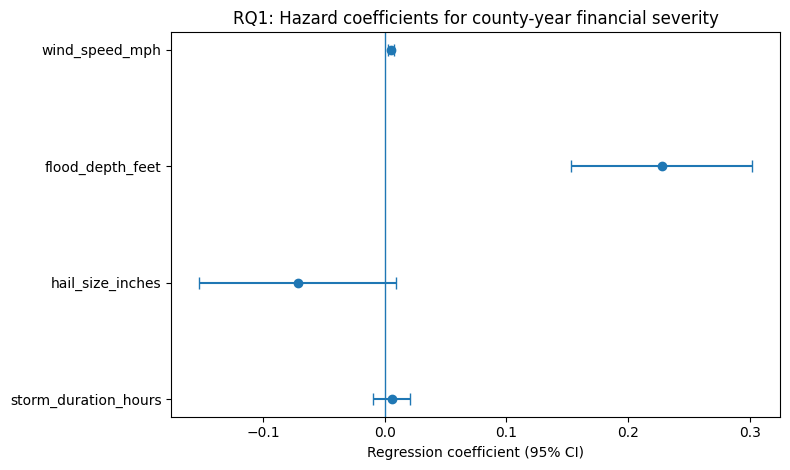

In [6]:
plotdf=coef1.query("Term != 'const'").copy().iloc[::-1]
fig,ax=plt.subplots(figsize=(8,4.8))
ax.errorbar(plotdf['Coefficient'],range(len(plotdf)),xerr=[plotdf['Coefficient']-plotdf['CI_95_Lower'],plotdf['CI_95_Upper']-plotdf['Coefficient']],fmt='o',capsize=4)
ax.axvline(0,linewidth=1)
ax.set_yticks(range(len(plotdf))); ax.set_yticklabels(plotdf['Term'])
ax.set_xlabel('Regression coefficient (95% CI)')
ax.set_title('RQ1: Hazard coefficients for county-year financial severity')
fig.tight_layout(); fig.savefig(FIG_DIR/'RQ1_hazard_coefficients_95CI.png',dpi=300,bbox_inches='tight'); plt.show()

# RQ2 — Socioeconomic Moderation
A standardized hazard-intensity index is computed as the mean of standardized wind speed, flood depth, hail size, and storm duration. Four pre-specified moderators are tested: median income, population density, housing age, and the socioeconomic resilience index. Because four interaction tests are performed, the Bonferroni-adjusted significance threshold is **0.0125**.

In [7]:
work=df.copy()
for c in hazard_features + ['median_income_usd','population_density_per_sq_mi','housing_age_median_years','socioeconomic_resilience_index']:
    work['z_'+c]=(work[c]-work[c].mean())/work[c].std(ddof=0)
work['hazard_intensity_index']=work[['z_'+c for c in hazard_features]].mean(axis=1)
moderators=['median_income_usd','population_density_per_sq_mi','housing_age_median_years','socioeconomic_resilience_index']
mod_rows=[]; mod_models={}
for mod in moderators:
    z='z_'+mod; inter='hazard_x_'+mod
    work[inter]=work['hazard_intensity_index']*work[z]
    mm=sm.OLS(work['financial_severity_log'],sm.add_constant(work[['hazard_intensity_index',z,inter]])).fit(cov_type='HC3')
    mod_models[mod]=mm
    mod_rows.append({
        'Moderator':mod,'Interaction_Coefficient':mm.params[inter],'Robust_SE':mm.bse[inter],
        'p_value':mm.pvalues[inter],'Bonferroni_alpha':.05/len(moderators),
        'Significant_after_Bonferroni':bool(mm.pvalues[inter] < .05/len(moderators)),
        'Adjusted_R_squared':mm.rsquared_adj
    })
rq2_table=pd.DataFrame(mod_rows).sort_values('p_value')
rq2_table.to_csv(TABLE_DIR/'07_RQ2_moderation_results.csv',index=False)
rq2_table

,Moderator,Interaction_Coefficient,Robust_SE,p_value,Bonferroni_alpha,Significant_after_Bonferroni,Adjusted_R_squared
0,median_income_usd,-0.317785,0.083270,0.000135,0.0125,True,0.042173
2,housing_age_median_years,0.115049,0.071840,0.109276,0.0125,False,0.031952
3,socioeconomic_resilience_index,-0.097187,0.071813,0.175952,0.0125,False,0.030313
1,population_density_per_sq_mi,0.091891,0.089130,0.302553,0.0125,False,0.026941


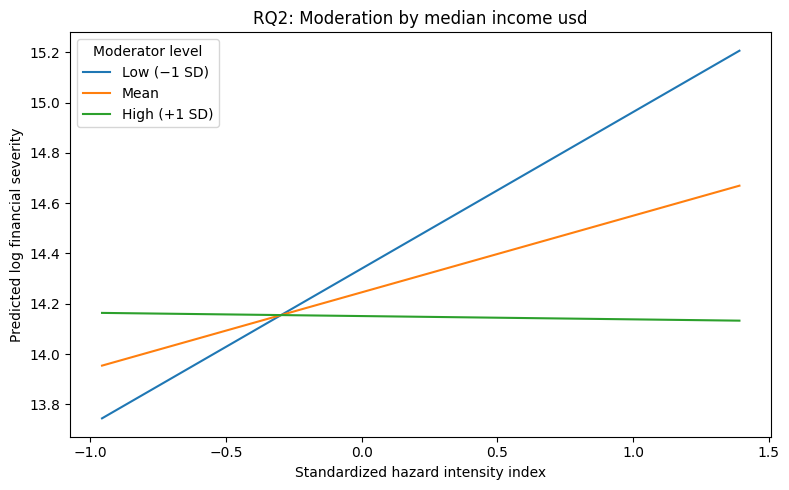

In [8]:
# Interaction visualization for the strongest moderator.
best_mod=rq2_table.iloc[0]['Moderator']
mm=mod_models[best_mod]
z='z_'+best_mod; inter='hazard_x_'+best_mod
hx=np.linspace(work['hazard_intensity_index'].quantile(.02),work['hazard_intensity_index'].quantile(.98),100)
fig,ax=plt.subplots(figsize=(8,5))
for level,label in [(-1,'Low (−1 SD)'),(0,'Mean'),(1,'High (+1 SD)')]:
    pred=(mm.params['const'] + mm.params['hazard_intensity_index']*hx + mm.params[z]*level + mm.params[inter]*hx*level)
    ax.plot(hx,pred,label=label)
ax.set_xlabel('Standardized hazard intensity index')
ax.set_ylabel('Predicted log financial severity')
ax.set_title(f'RQ2: Moderation by {best_mod.replace("_"," ")}')
ax.legend(title='Moderator level')
fig.tight_layout(); fig.savefig(FIG_DIR/'RQ2_strongest_moderation_interaction.png',dpi=300,bbox_inches='tight'); plt.show()

# RQ3 — Leakage-Safe Classification of High Financial Severity
### Final classification target
`high_financial_severity_flag = 1` for the top 20% of `financial_severity_log`.

### Leakage-safe predictors
Only hazard descriptors, socioeconomic context, event category, construction type, and state are used. **No claim payout, property damage, total observed loss, transformed loss, interim severity metric, or interim high-severity flag is used as a predictor.**

### Validation design
- Training period: **2000–2018**
- Independent temporal holdout: **2019–2023**
- 5-fold stratified cross-validation within the training period
- Logistic Regression is included as an interpretable baseline; Random Forest, Gradient Boosting, and XGBoost are the requested ensemble models.

In [9]:
num_features=['hazard_event_count','event_type_count','wind_speed_mph','hail_size_inches','flood_depth_feet','storm_duration_hours',
              'median_income_usd','population_density_per_sq_mi','housing_age_median_years','vacancy_rate_pct','homeownership_rate_pct','pct_units_pre1980']
cat_features=['dominant_event_type','construction_type','state']
feature_cols=num_features+cat_features

train=df[df['year']<=2018].copy(); test=df[df['year']>=2019].copy()
X_train=train[feature_cols]; y_train=train['high_financial_severity_flag']
X_test=test[feature_cols]; y_test=test['high_financial_severity_flag']

preprocessor=ColumnTransformer([
    ('num',Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num_features),
    ('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False))]),cat_features),
])
ratio=(len(y_train)-y_train.sum())/y_train.sum()
models={
    'Logistic Regression':LogisticRegression(max_iter=2000,class_weight='balanced',random_state=42),
    'Random Forest':RandomForestClassifier(n_estimators=500,max_depth=8,min_samples_leaf=3,class_weight='balanced',random_state=42,n_jobs=-1),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=150,learning_rate=.04,max_depth=2,random_state=42),
}
if XGBOOST_AVAILABLE:
    models['XGBoost']=XGBClassifier(n_estimators=250,max_depth=3,learning_rate=.03,subsample=.85,colsample_bytree=.85,
                                    eval_metric='logloss',random_state=42,n_jobs=2,scale_pos_weight=ratio)

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
rq3_rows=[]; fitted={}; predictions={}
for name,model in models.items():
    pipe=Pipeline([('pre',preprocessor),('model',model)])
    if name=='Gradient Boosting':
        sw=np.where(y_train==1,ratio,1.0)
        pipe.fit(X_train,y_train,model__sample_weight=sw)
    else:
        pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test); prob=pipe.predict_proba(X_test)[:,1]
    # CV AUC (without sample-weighted GB to keep CV pipeline simple/consistent)
    cv_auc=cross_val_score(pipe,X_train,y_train,cv=cv,scoring='roc_auc',n_jobs=1).mean() if name!='Gradient Boosting' else np.nan
    rq3_rows.append({
        'Model':name,'Training_N':len(train),'Test_N':len(test),'Test_High_Severity_N':int(y_test.sum()),
        'Accuracy':accuracy_score(y_test,pred),'Precision':precision_score(y_test,pred,zero_division=0),
        'Recall':recall_score(y_test,pred,zero_division=0),'F1':f1_score(y_test,pred,zero_division=0),
        'ROC_AUC':roc_auc_score(y_test,prob),'PR_AUC':average_precision_score(y_test,prob),'CV_ROC_AUC_Mean':cv_auc
    })
    fitted[name]=pipe; predictions[name]=(pred,prob)
    joblib.dump(pipe,MODEL_DIR/(name.lower().replace(' ','_')+'_pipeline.joblib'))

rq3_perf=pd.DataFrame(rq3_rows).sort_values('ROC_AUC',ascending=False)
rq3_perf.to_csv(TABLE_DIR/'08_RQ3_model_performance_temporal_holdout.csv',index=False)
rq3_perf

,Model,Training_N,Test_N,Test_High_Severity_N,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,CV_ROC_AUC_Mean
0,Logistic Regression,710,193,39,0.616580,0.283951,0.589744,0.383333,0.646687,0.488096,0.565674
1,Random Forest,710,193,39,0.813472,0.578947,0.282051,0.379310,0.610889,0.424931,0.556888
2,Gradient Boosting,710,193,39,0.606218,0.259740,0.512821,0.344828,0.567766,0.443982,NaN
3,XGBoost,710,193,39,0.673575,0.269231,0.358974,0.307692,0.558608,0.336156,0.526380


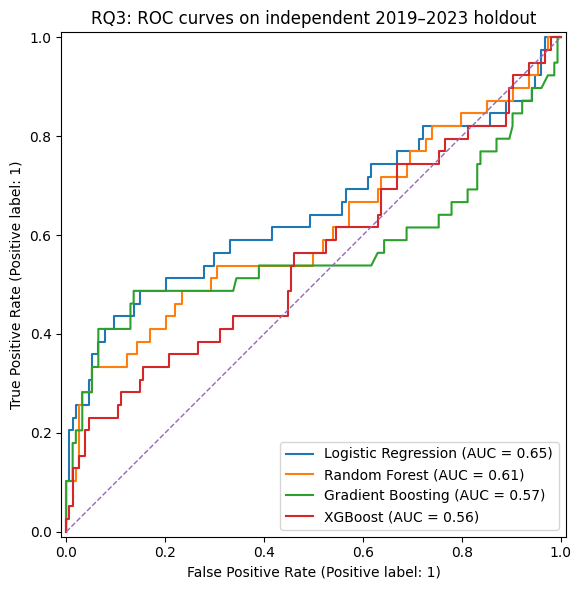

In [10]:
fig,ax=plt.subplots(figsize=(7.5,6))
for name,(pred,prob) in predictions.items():
    RocCurveDisplay.from_predictions(y_test,prob,name=name,ax=ax)
ax.plot([0,1],[0,1],'--',linewidth=1)
ax.set_title('RQ3: ROC curves on independent 2019–2023 holdout')
fig.tight_layout(); fig.savefig(FIG_DIR/'RQ3_ROC_curves_temporal_holdout.png',dpi=300,bbox_inches='tight'); plt.show()

# Confusion matrices as report-ready CSVs.
for name,(pred,prob) in predictions.items():
    cm=confusion_matrix(y_test,pred)
    pd.DataFrame(cm,index=['Actual 0','Actual 1'],columns=['Predicted 0','Predicted 1']).to_csv(TABLE_DIR/f'RQ3_confusion_matrix_{name.lower().replace(" ","_")}.csv')

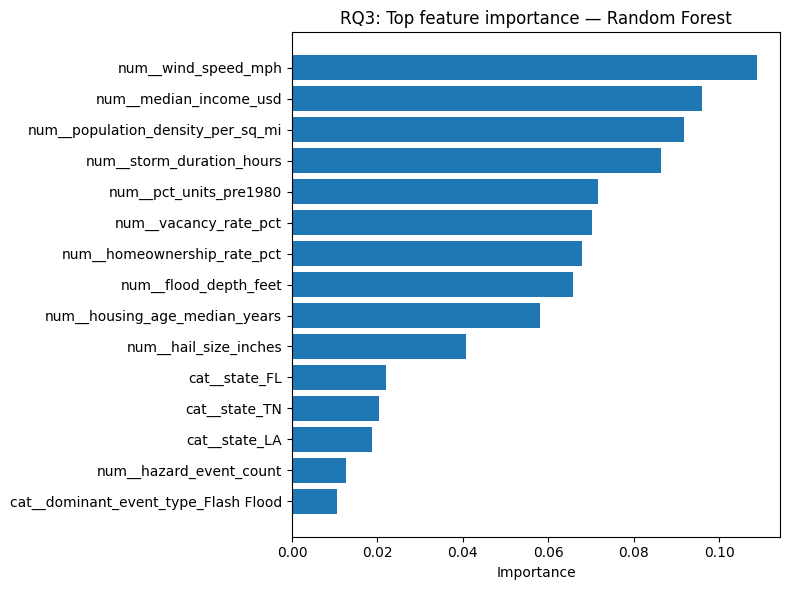

Best ensemble by temporal-holdout ROC-AUC: Random Forest


In [11]:
# Feature importance for the best-performing ensemble by ROC-AUC.
ensemble_names=[n for n in rq3_perf['Model'] if n!='Logistic Regression']
best_ensemble=max(ensemble_names,key=lambda n:float(rq3_perf.loc[rq3_perf.Model==n,'ROC_AUC'].iloc[0]))
pipe=fitted[best_ensemble]
feature_names=pipe.named_steps['pre'].get_feature_names_out()
model=pipe.named_steps['model']
if hasattr(model,'feature_importances_'):
    imp=model.feature_importances_
else:
    imp=np.zeros(len(feature_names))
fi=pd.DataFrame({'Feature':feature_names,'Importance':imp}).sort_values('Importance',ascending=False)
fi.to_csv(TABLE_DIR/'09_RQ3_feature_importance_best_ensemble.csv',index=False)
plotfi=fi.head(15).iloc[::-1]
fig,ax=plt.subplots(figsize=(8,6)); ax.barh(plotfi['Feature'],plotfi['Importance']); ax.set_xlabel('Importance'); ax.set_title(f'RQ3: Top feature importance — {best_ensemble}')
fig.tight_layout(); fig.savefig(FIG_DIR/'RQ3_feature_importance_best_ensemble.png',dpi=300,bbox_inches='tight'); plt.show()
print('Best ensemble by temporal-holdout ROC-AUC:',best_ensemble)

# RQ4 — Long-Term Trend and ARIMA
Annual mean `financial_severity_log` is used. The Mann–Kendall test evaluates monotonic trend significance. Theil–Sen slope provides a robust trend magnitude and confidence interval. ARIMA candidates are compared by AIC; the selected model is used for a five-year illustrative forecast.

In [12]:
annual=df.groupby('year',as_index=False)['financial_severity_log'].mean()
y=annual['financial_severity_log'].to_numpy(); years=annual['year'].to_numpy(); n=len(y)
S=0
for i in range(n-1): S += np.sign(y[i+1:]-y[i]).sum()
# no exact ties at annual mean precision in this dataset; standard MK variance
varS=n*(n-1)*(2*n+5)/18
z=(S-1)/np.sqrt(varS) if S>0 else ((S+1)/np.sqrt(varS) if S<0 else 0)
p_mk=2*(1-norm.cdf(abs(z)))
tau=stats.kendalltau(years,y).statistic
sen=theilslopes(y,years,0.95)
mk=pd.DataFrame([{'N_years':n,'S':S,'Var_S':varS,'Z':z,'p_value':p_mk,'Kendall_tau':tau,
                  'Sen_slope_per_year':sen.slope,'Sen_slope_CI_low':sen.low_slope,'Sen_slope_CI_high':sen.high_slope,
                  'Decision_at_0_05':'Reject H0' if p_mk<.05 and sen.slope>0 else 'Fail to reject H0'}])
mk.to_csv(TABLE_DIR/'10_RQ4_mann_kendall_results.csv',index=False)
mk

,N_years,S,Var_S,Z,p_value,Kendall_tau,Sen_slope_per_year,Sen_slope_CI_low,Sen_slope_CI_high,Decision_at_0_05
0,24,32.0,1625.333333,0.768936,0.441931,0.115942,0.005605,-0.007296,0.017419,Fail to reject H0


In [13]:
# ARIMA order search (small grid appropriate for 24 annual observations).
rows=[]; fits={}
for p in range(0,4):
    for d in range(0,2):
        for q in range(0,4):
            if p==d==q==0: continue
            try:
                fit=ARIMA(y,order=(p,d,q),trend='t').fit()
                converged=bool(fit.mle_retvals.get('converged',True))
                rows.append({'p':p,'d':d,'q':q,'AIC':fit.aic,'BIC':fit.bic,'Converged':converged})
                fits[(p,d,q)]=fit
            except Exception:
                pass
arima_grid=pd.DataFrame(rows).sort_values(['Converged','AIC'],ascending=[False,True])
arima_grid.to_csv(TABLE_DIR/'11_RQ4_ARIMA_candidate_models.csv',index=False)
best_row=arima_grid[arima_grid.Converged].sort_values('AIC').iloc[0]
best_order=tuple(int(best_row[c]) for c in ['p','d','q']); best_fit=fits[best_order]
forecast=best_fit.get_forecast(steps=5)
ci=forecast.conf_int(alpha=.05)
forecast_years=np.arange(years.max()+1,years.max()+6)
fc=pd.DataFrame({'Year':forecast_years,'Forecast_financial_severity_log':forecast.predicted_mean,'CI_95_Lower':ci[:,0],'CI_95_Upper':ci[:,1]})
fc.to_csv(TABLE_DIR/'12_RQ4_ARIMA_forecast.csv',index=False)
with open(MODEL_DIR/'rq4_arima_model.pkl','wb') as fobj: pickle.dump(best_fit,fobj)
print('Best converged ARIMA order:',best_order,'AIC=',best_fit.aic)
fc

/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best converged ARIMA order: (0, 1, 1) AIC= -4.187601573151287


/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/pyvenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Year,Forecast_financial_severity_log,CI_95_Lower,CI_95_Upper
0,2024,14.388987,14.015461,14.762512
1,2025,14.393275,14.007351,14.779199
2,2026,14.397564,13.999628,14.795500
3,2027,14.401853,13.992257,14.811449
4,2028,14.406142,13.985209,14.827075


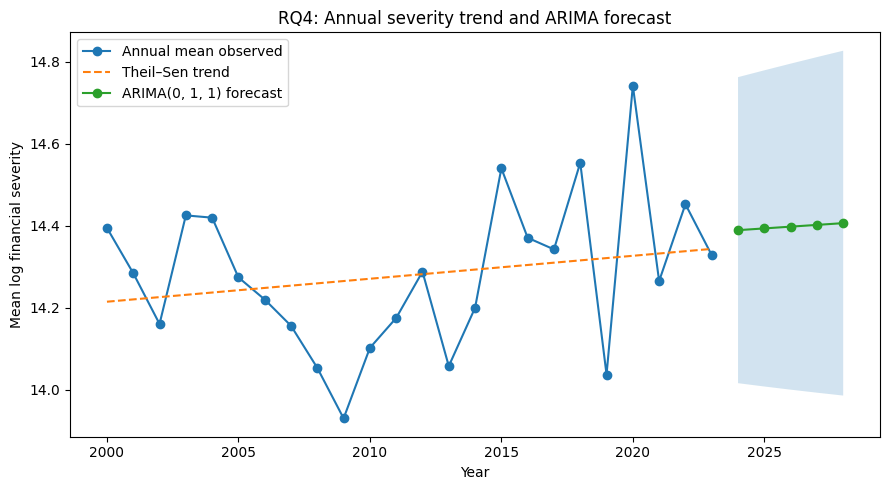

In [14]:
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(years,y,marker='o',label='Annual mean observed')
trend=sen.intercept+sen.slope*years
ax.plot(years,trend,linestyle='--',label='Theil–Sen trend')
ax.plot(fc['Year'],fc['Forecast_financial_severity_log'],marker='o',label=f'ARIMA{best_order} forecast')
ax.fill_between(fc['Year'].to_numpy(),fc['CI_95_Lower'].to_numpy(),fc['CI_95_Upper'].to_numpy(),alpha=.2)
ax.set_xlabel('Year'); ax.set_ylabel('Mean log financial severity'); ax.set_title('RQ4: Annual severity trend and ARIMA forecast'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR/'RQ4_annual_trend_and_ARIMA_forecast.png',dpi=300,bbox_inches='tight'); plt.show()

# RQ Decisions — Modeling Stage
These decisions use the final leakage-controlled targets and are intended for the final report. They should be interpreted together with the evaluation and robustness checks in `04_Evaluation.ipynb`.

In [15]:
# RQ1 decision
rq1_sig=bool(rq1.f_pvalue < .05)
# RQ2 decision: any pre-specified moderation interaction survives Bonferroni
rq2_sig=bool(rq2_table['Significant_after_Bonferroni'].any())
# RQ3 decision: compare best ensemble AUC to random 0.5; formal bootstrap CI in evaluation notebook
best_ens_row=rq3_perf[rq3_perf.Model!='Logistic Regression'].sort_values('ROC_AUC',ascending=False).iloc[0]
# RQ4 decision from MK
rq4_sig=bool((p_mk<.05) and (sen.slope>0))

summary_rq=pd.DataFrame([
    ['RQ1','Hazard variables jointly predict financial severity','Reject H0' if rq1_sig else 'Fail to reject H0',f"Robust F p={rq1.f_pvalue:.3g}; adj. R²={rq1.rsquared_adj:.3f}"],
    ['RQ2','Socioeconomic moderation exists','Reject H0' if rq2_sig else 'Fail to reject H0',f"Smallest adjusted interaction p={rq2_table.p_value.min():.3g}; Bonferroni alpha=.0125"],
    ['RQ3','Leakage-safe ensemble classification exceeds random','Pending formal CI in 04_Evaluation.ipynb',f"Best ensemble={best_ens_row.Model}; temporal-holdout AUC={best_ens_row.ROC_AUC:.3f}"],
    ['RQ4','Financial severity increased over time','Reject H0' if rq4_sig else 'Fail to reject H0',f"MK p={p_mk:.3f}; Sen slope={sen.slope:.4f}/year"],
],columns=['RQ','Hypothesis focus','Current decision','Key evidence'])
summary_rq.to_csv(TABLE_DIR/'13_RQ_modeling_results_summary.csv',index=False)
summary_rq

,RQ,Hypothesis focus,Current decision,Key evidence
0,RQ1,Hazard variables jointly predict financial sev...,Reject H0,Robust F p=7.06e-20; adj. R²=0.069
1,RQ2,Socioeconomic moderation exists,Reject H0,Smallest adjusted interaction p=0.000135; Bonf...
2,RQ3,Leakage-safe ensemble classification exceeds r...,Pending formal CI in 04_Evaluation.ipynb,Best ensemble=Random Forest; temporal-holdout ...
3,RQ4,Financial severity increased over time,Fail to reject H0,MK p=0.442; Sen slope=0.0056/year
